In [274]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

In [182]:
df_matches = pd.read_csv('epl_matches_15.csv')
df_matches.info()
df_matches.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Unnamed: 0                    380 non-null    int64 
 1   match_id                      380 non-null    int64 
 2   match_date                    380 non-null    object
 3   kick_off                      380 non-null    object
 4   home_score                    380 non-null    int64 
 5   away_score                    380 non-null    int64 
 6   match_status                  380 non-null    object
 7   last_updated                  380 non-null    object
 8   match_week                    380 non-null    int64 
 9   competition.competition_id    380 non-null    int64 
 10  competition.country_name      380 non-null    object
 11  competition.competition_name  380 non-null    object
 12  season.season_id              380 non-null    int64 
 13  season.season_name  

,Unnamed: 0,match_id,match_date,kick_off,home_score,away_score,match_status,last_updated,match_week,competition.competition_id,competition.country_name,competition.competition_name,season.season_id,season.season_name,home_team.home_team_id,home_team.home_team_name,home_team.managers,away_team.away_team_id,away_team.away_team_name,away_team.managers,competition_stage.id,competition_stage.name,stadium.id,stadium.name,referee.id,referee.name,referee.country.id,referee.country.name
0,1,3754058,2016-01-02,16:00:00.000,0,0,available,2021-10-29T23:44:19.940296,20,2,England,Premier League,27,2015/2016,22,Leicester City,"60, Claudio Ranieri, NA, 1951-10-20, 112, Italy",28,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",1,Regular Season,20,King Power Stadium,5,Andre Marriner,68,England
1,2,3754245,2015-10-17,16:00:00.000,1,0,available,2022-12-01T13:09:17.044015,9,2,England,Premier League,27,2015/2016,27,West Bromwich Albion,"300, Tony Pulis, NA, 1958-01-16, 249, Wales",41,Sunderland,"561, Sam Allardyce, NA, 1954-10-19, 68, England",1,Regular Season,33,The Hawthorns,4,Martin Atkinson,68,England
2,3,3754136,2015-12-19,18:30:00.000,1,1,available,2020-11-12T23:48:19.757269,17,2,England,Premier League,27,2015/2016,37,Newcastle United,"40, Steve McClaren, NA, 1961-05-03, 68, England",59,Aston Villa,"92, Rémi Garde, NA, 1966-04-03, 78, France",1,Regular Season,4674,St. James'' Park,4,Martin Atkinson,68,England
3,4,3754037,2016-04-30,16:00:00.000,2,1,available,2021-07-07T17:59:57.456,36,2,England,Premier League,27,2015/2016,29,Everton,"263, Roberto Martínez Montoliú, Roberto Martín...",28,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",1,Regular Season,12,Goodison Park,7,Neil Swarbrick,68,England
4,5,3754039,2016-02-13,16:00:00.000,1,2,available,2021-07-25T18:09:51.386,26,2,England,Premier League,27,2015/2016,31,Crystal Palace,"382, Alan Pardew, NA, 1961-07-18, 68, England",23,Watford,"236, Enrique Sánchez Flores, Quique Sánchez Fl...",1,Regular Season,37,Selhurst Park,9,Robert Madley,68,England


In [183]:
df_event = pd.read_csv('epl_event_data_15.csv')
df_event.info()
df_event.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313783 entries, 0 to 1313782
Data columns (total 49 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Unnamed: 0                 1313783 non-null  int64  
 1   id                         1313783 non-null  object 
 2   index                      1313783 non-null  int64  
 3   period                     1313783 non-null  int64  
 4   timestamp                  1313783 non-null  object 
 5   minute                     1313783 non-null  int64  
 6   second                     1313783 non-null  int64  
 7   possession                 1313783 non-null  int64  
 8   duration                   973459 non-null   float64
 9   related_events             1258785 non-null  object 
 10  location                   1305706 non-null  object 
 11  under_pressure             279690 non-null   object 
 12  counterpress               42350 non-null    object 
 13  type.id     

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,location,under_pressure,counterpress,type.id,type.name,possession_team.id,possession_team.name,play_pattern.id,play_pattern.name,team.id,team.name,tactics.formation,tactics.lineup,player.id,player.name,position.id,position.name,pass.length,pass.angle,pass.height.id,pass.height.name,pass.body_part.id,pass.body_part.name,pass.type.id,pass.type.name,pass.outcome.id,pass.outcome.name,pass.receipient.id,pass.recipient.name,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
0,1,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,1,0.000000,NaN,NaN,NaN,NaN,35,Starting XI,22,Leicester City,1,Regular Play,22,Leicester City,442.0,"1, 17, 5, 6, 28, 14, 26, 4, 11, 23, 9, 3815, 3...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
1,2,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,1,0.000000,NaN,NaN,NaN,NaN,35,Starting XI,22,Leicester City,1,Regular Play,28,AFC Bournemouth,4141.0,"1, 15, 2, 3, 11, 6, 30, 4, 8, 19, 17, 20074, 6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
2,3,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,1,0.000000,100362ee-9311-4187-bd8a-0201d9db2565,NaN,NaN,NaN,18,Half Start,22,Leicester City,1,Regular Play,28,AFC Bournemouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
3,4,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,1,0.000000,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,NaN,NaN,NaN,18,Half Start,22,Leicester City,1,Regular Play,22,Leicester City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
4,5,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,2,0.308263,1f98c89e-2326-4200-8c12-a987fdbbaf2e,"61, 40.1",NaN,NaN,30,Pass,28,AFC Bournemouth,9,From Kick Off,28,AFC Bournemouth,NaN,NaN,3343.0,Dan Gosling,13.0,Right Center Midfield,3.551056,1.740575,1.0,Ground Pass,40.0,Right Foot,65.0,Kick Off,NaN,NaN,NaN,Joshua King,"60.4, 43.6",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058


In [184]:
df_merged = df_event.merge(
    df_matches,
    on='match_id',
    how='left'
)

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313783 entries, 0 to 1313782
Data columns (total 76 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   Unnamed: 0_x                  1313783 non-null  int64  
 1   id                            1313783 non-null  object 
 2   index                         1313783 non-null  int64  
 3   period                        1313783 non-null  int64  
 4   timestamp                     1313783 non-null  object 
 5   minute                        1313783 non-null  int64  
 6   second                        1313783 non-null  int64  
 7   possession                    1313783 non-null  int64  
 8   duration                      973459 non-null   float64
 9   related_events                1258785 non-null  object 
 10  location                      1305706 non-null  object 
 11  under_pressure                279690 non-null   object 
 12  counterpress                

### To find the target variable :-
- Sort by match, possession, and time.

- Find rows where the player receives or recovers the ball.

- For each such row, check later events in the same possession.

- Set won_foul = 1 if a foul won occurs later in that possession

In [185]:

df = df_merged.sort_values(['match_id', 'possession', 'period', 'minute', 'second']).copy()

df['foul_won_later'] = (
    df.groupby(['match_id', 'possession'])['type.name']
      .transform(lambda s: s.eq('Foul Won')[::-1].cummax()[::-1])
)

df_start = df[df['type.name'].isin(['Ball Receipt*', 'Ball Recovery'])].copy()
df_start['won_foul'] = df_start['foul_won_later'].astype(int)

In [186]:
df_start['foul_won_later'].value_counts()

foul_won_later
False    339529
True      41738
Name: count, dtype: int64

In [187]:
pd.set_option('display.max_columns', None)
df_start.describe()

,Unnamed: 0_x,index,period,minute,second,possession,duration,type.id,possession_team.id,play_pattern.id,team.id,tactics.formation,player.id,position.id,pass.length,pass.angle,pass.height.id,pass.body_part.id,pass.type.id,pass.outcome.id,pass.receipient.id,dribble.outcome.id,ball_receipt.outcome.id,duel.outcome.id,competition_id,match_id,Unnamed: 0_y,home_score,away_score,match_week,competition.competition_id,season.season_id,home_team.home_team_id,away_team.away_team_id,competition_stage.id,stadium.id,referee.id,referee.country.id,won_foul
count,3.812670e+05,381267.000000,381267.000000,381267.000000,381267.000000,381267.000000,40943.000000,381267.000000,381267.000000,381267.000000,381267.000000,0.0,381267.000000,381267.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57945.0,0.0,381267.0,3.812670e+05,381267.000000,381267.000000,381267.000000,381267.000000,381267.0,381267.0,381267.000000,381267.000000,381267.0,381267.000000,381267.000000,381267.0,381267.000000
mean,6.554588e+05,1728.393409,1.488416,44.628350,29.282262,92.618498,0.000559,37.704533,31.747348,2.953104,31.776729,NaN,7514.689060,12.460585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.754161e+06,191.206428,1.503214,1.215054,19.556702,2.0,27.0,32.061566,32.151057,1.0,11268.216056,65.900303,68.0,0.109472
std,3.791009e+05,1017.164636,0.499866,27.029716,17.350862,54.948467,0.025921,12.384186,12.278757,2.248410,12.263134,NaN,9179.287718,7.322855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,1.098733e+02,109.686849,1.269991,1.156380,10.986437,0.0,0.0,12.249176,12.153989,0.0,31398.324918,196.359864,0.0,0.312231
min,6.000000e+00,6.000000,1.000000,0.000000,0.000000,2.000000,0.000000,2.000000,1.000000,1.000000,1.000000,NaN,2956.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.753972e+06,1.000000,0.000000,0.000000,1.000000,2.0,27.0,1.000000,1.000000,1.0,2.000000,1.000000,68.0,0.000000
25%,3.272575e+05,851.000000,1.000000,21.000000,14.000000,45.000000,0.000000,42.000000,25.000000,1.000000,25.000000,NaN,3437.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.754066e+06,96.000000,1.000000,0.000000,10.000000,2.0,27.0,25.000000,26.000000,1.0,12.000000,4.000000,68.0,0.000000
50%,6.544580e+05,1710.000000,1.000000,45.000000,29.000000,91.000000,0.000000,42.000000,30.000000,3.000000,30.000000,NaN,3650.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.754161e+06,192.000000,1.000000,1.000000,20.000000,2.0,27.0,30.000000,30.000000,1.0,45.000000,8.000000,68.0,0.000000
75%,9.835810e+05,2579.000000,2.000000,67.000000,44.000000,138.000000,0.000000,42.000000,38.000000,4.000000,38.000000,NaN,6870.000000,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.754257e+06,286.000000,2.000000,2.000000,29.000000,2.0,27.0,38.000000,38.000000,1.0,4589.000000,12.000000,68.0,0.000000
max,1.313781e+06,4262.000000,2.000000,100.000000,59.000000,238.000000,2.623528,42.000000,59.000000,9.000000,59.000000,NaN,129559.000000,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,2.0,3.754351e+06,380.000000,6.000000,6.000000,38.000000,2.0,27.0,59.000000,59.000000,1.0,115324.000000,728.000000,68.0,1.000000


array([[<Axes: title={'center': 'Unnamed: 0_x'}>,
        <Axes: title={'center': 'index'}>,
        <Axes: title={'center': 'period'}>,
        <Axes: title={'center': 'minute'}>,
        <Axes: title={'center': 'second'}>,
        <Axes: title={'center': 'possession'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'type.id'}>,
        <Axes: title={'center': 'possession_team.id'}>,
        <Axes: title={'center': 'play_pattern.id'}>,
        <Axes: title={'center': 'team.id'}>,
        <Axes: title={'center': 'tactics.formation'}>],
       [<Axes: title={'center': 'player.id'}>,
        <Axes: title={'center': 'position.id'}>,
        <Axes: title={'center': 'pass.length'}>,
        <Axes: title={'center': 'pass.angle'}>,
        <Axes: title={'center': 'pass.height.id'}>,
        <Axes: title={'center': 'pass.body_part.id'}>],
       [<Axes: title={'center': 'pass.type.id'}>,
        <Axes: title={'center': 'pass.outcome.id'}>,
        <Axes: title=

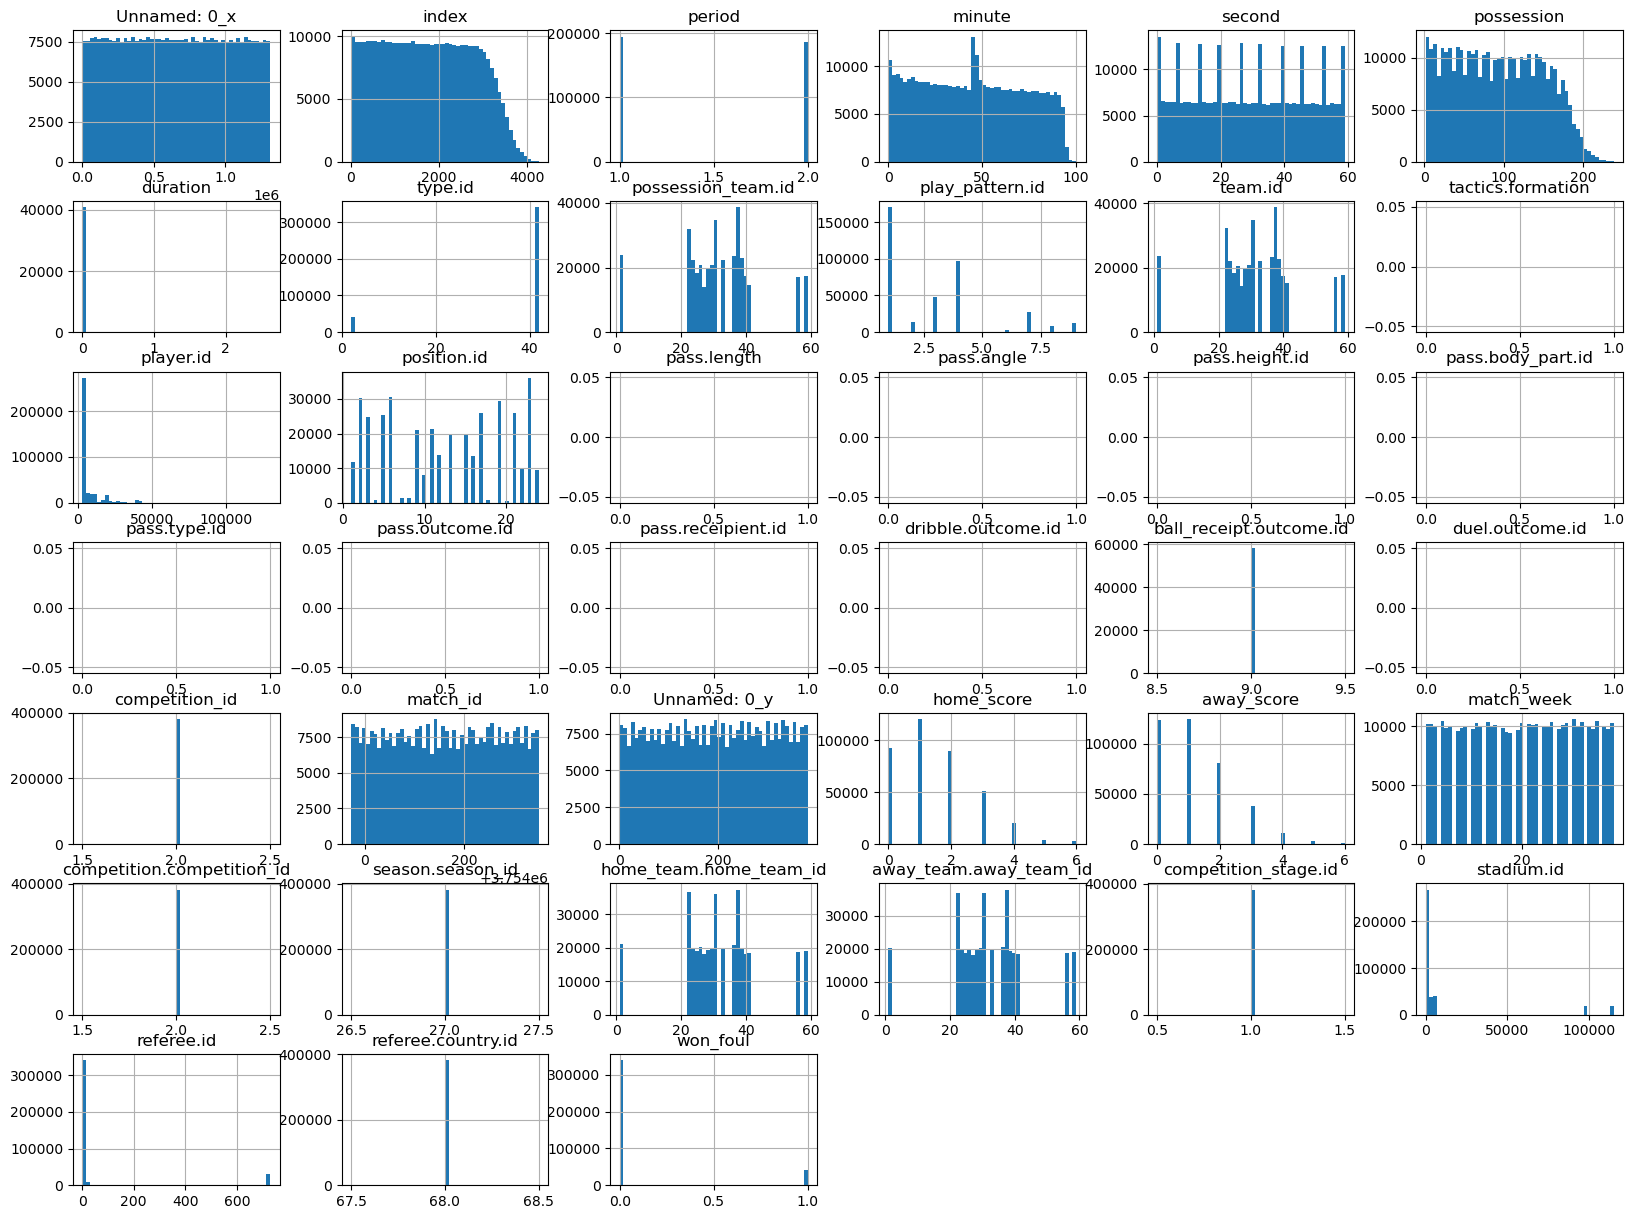

In [188]:
df_start.hist(bins=50, figsize=(20,15))

In [189]:
df_start.describe(include='object')

,id,timestamp,related_events,location,under_pressure,counterpress,type.name,possession_team.name,play_pattern.name,team.name,tactics.lineup,player.name,position.name,pass.height.name,pass.body_part.name,pass.type.name,pass.outcome.name,pass.recipient.name,pass.end_location,dribble.outcome.name,ball_receipt.outcome.name,carry.end_location,duel.outcome.name,match_date,kick_off,match_status,last_updated,competition.country_name,competition.competition_name,season.season_name,home_team.home_team_name,home_team.managers,away_team.away_team_name,away_team.managers,competition_stage.name,stadium.name,referee.name,referee.country.name
count,381267,381267,360011,381267,34829,0,381267,381267,381267,381267,0,381267,381267,0,0,0,0,0,0,0,57945,0,0,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267,381267
unique,381267,349153,351732,290163,1,0,2,20,9,20,0,548,24,0,0,0,0,0,0,0,1,0,0,99,12,1,348,1,1,1,20,31,20,30,1,20,19,1
top,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,00:00:00.914,4264436f-4a71-452f-b5f3-44cd5bb04dbb,"69.3, 62.2",True,NaN,Ball Receipt*,Arsenal,Regular Play,Arsenal,NaN,Francesc Fàbregas i Soler,Center Forward,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Incomplete,NaN,NaN,2015-12-26,16:00:00.000,available,2020-07-29T05:00,England,Premier League,2015/2016,Arsenal,"577, Arsène Wenger, NA, 1949-10-22, 78, France",Manchester City,"733, Manuel Luis Pellegrini Ripamonti, Manuel ...",Regular Season,Emirates Stadium,Mike Dean,England
freq,1,6,2,8,34829,NaN,340324,23906,170203,23585,NaN,2892,36106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57945,NaN,NaN,9391,180227,381267,8839,381267,381267,381267,21084,21084,20397,20397,381267,21084,33091,381267


In [190]:
df_start.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0_x                  381267 non-null  int64  
 1   id                            381267 non-null  object 
 2   index                         381267 non-null  int64  
 3   period                        381267 non-null  int64  
 4   timestamp                     381267 non-null  object 
 5   minute                        381267 non-null  int64  
 6   second                        381267 non-null  int64  
 7   possession                    381267 non-null  int64  
 8   duration                      40943 non-null   float64
 9   related_events                360011 non-null  object 
 10  location                      381267 non-null  object 
 11  under_pressure                34829 non-null   object 
 12  counterpress                  0 non-null     

In [191]:
df_start.columns

Index(['Unnamed: 0_x', 'id', 'index', 'period', 'timestamp', 'minute',
       'second', 'possession', 'duration', 'related_events', 'location',
       'under_pressure', 'counterpress', 'type.id', 'type.name',
       'possession_team.id', 'possession_team.name', 'play_pattern.id',
       'play_pattern.name', 'team.id', 'team.name', 'tactics.formation',
       'tactics.lineup', 'player.id', 'player.name', 'position.id',
       'position.name', 'pass.length', 'pass.angle', 'pass.height.id',
       'pass.height.name', 'pass.body_part.id', 'pass.body_part.name',
       'pass.type.id', 'pass.type.name', 'pass.outcome.id',
       'pass.outcome.name', 'pass.receipient.id', 'pass.recipient.name',
       'pass.end_location', 'dribble.outcome.id', 'dribble.outcome.name',
       'ball_receipt.outcome.id', 'ball_receipt.outcome.name',
       'carry.end_location', 'duel.outcome.id', 'duel.outcome.name',
       'competition_id', 'match_id', 'Unnamed: 0_y', 'match_date', 'kick_off',
       'home_score

In [192]:
df_start['competition_stage.name'].value_counts()

competition_stage.name
Regular Season    381267
Name: count, dtype: int64

In [193]:
df_start['match_status'].value_counts()

match_status
available    381267
Name: count, dtype: int64

In [194]:
df_start['last_updated'].value_counts()

last_updated
2020-07-29T05:00              8839
2020-11-29T14:07:50.969020    5234
2020-09-11T18:18:25.317407    4971
2020-09-09T11:03:23.049831    3369
2020-09-09T12:35:13.376459    3179
                              ... 
2022-12-01T14:27:17.645361     780
2021-07-06T18:13:15.148        776
2020-08-10T22:04:56.027298     769
2022-12-01T14:23:40.009813     760
2021-07-07T18:12:56.866        752
Name: count, Length: 348, dtype: int64

In [195]:
# will keep this column
df_start['match_week'].value_counts()


match_week
30    10612
35    10431
4     10430
26    10355
32    10354
13    10331
38    10285
11    10284
20    10256
29    10250
23    10208
2     10200
21    10174
1     10151
15    10124
28    10123
22    10090
36    10060
24    10054
31    10045
25    10045
6      9965
12     9957
3      9922
14     9909
33     9906
9      9896
16     9886
8      9834
5      9825
37     9800
10     9790
34     9783
27     9744
19     9704
7      9618
17     9475
18     9391
Name: count, dtype: int64

In [196]:
df_start['competition_id'].value_counts()   

competition_id
2    381267
Name: count, dtype: int64

In [197]:
df_start['competition.country_name'].value_counts()   

competition.country_name
England    381267
Name: count, dtype: int64

In [198]:
df_start['competition.competition_name'].value_counts()   

competition.competition_name
Premier League    381267
Name: count, dtype: int64

In [199]:
df_start['season.season_name'].value_counts()   

season.season_name
2015/2016    381267
Name: count, dtype: int64

In [200]:
(df_start['team.name'] != df_start['possession_team.name']).value_counts(dropna=False)

False    351903
True      29364
Name: count, dtype: int64

In [201]:
df_start['competition_stage.name'].value_counts()

competition_stage.name
Regular Season    381267
Name: count, dtype: int64

In [202]:
df_start['timestamp'].value_counts()

timestamp
00:00:00.914    6
00:11:33.428    5
00:34:37.454    5
00:31:14.962    5
00:33:43.846    5
               ..
00:06:15.584    1
00:06:03.274    1
00:05:04.581    1
00:04:59.595    1
00:48:55.036    1
Name: count, Length: 349153, dtype: int64

In [203]:
df_start['referee.country.name'].value_counts()

referee.country.name
England    381267
Name: count, dtype: int64

In [204]:
(df_start['home_team.home_team_name'] != df_start['stadium.name']).value_counts(dropna=False)

True    381267
Name: count, dtype: int64

In [205]:
#dropping variables based on usability and high null values
df_dropped = df_start.copy()

drop_cols = [
    'Unnamed: 0_x', 
    'id', 
    'index',
    'duration',
    'type.name',
    'counterpress',
    'tactics.formation',
    'tactics.lineup',
    'pass.length',                  
    'pass.angle',                    
    'pass.height.id',                
    'pass.height.name',            
    'pass.body_part.id',             
    'pass.body_part.name',          
    'pass.type.id',                 
    'pass.type.name',              
    'pass.outcome.id',              
    'pass.outcome.name',            
    'pass.receipient.id',            
    'pass.recipient.name',          
    'pass.end_location',            
    'dribble.outcome.id',           
    'dribble.outcome.name',         
    'carry.end_location',
    'Unnamed: 0_y', 
    'match_date',
    'ball_receipt.outcome.id', 
    'ball_receipt.outcome.name',
    'duel.outcome.id', 
    'duel.outcome.name',
    'match_id',
    'foul_won_later',
    'second',
    'related_events',
    'play_pattern.id',
    'position.id',
    'home_team.home_team_id',
    'away_team.away_team_id',
    'competition_stage.id',
    'team.id',
    'stadium.id',
    'referee.id',
    'referee.country.id',
    'possession_team.id',
    'team.id',
    'player_id',
    'player.id',
    'competition_id',
    'type.id',
    'season.season_id'
    'competition_stage.name',
    'match_status',
    'last_updated',
    'competition.country_name',
    'competition.competition_name',
    'season.season_name',
    'competition_stage.name',
    'timestamp',
    'season.season_id',
    'referee.country.name',
    'stadium.name',
    'kick_off',
    'competition.competition_id'
]

df_dropped = df_dropped.drop(columns=drop_cols, errors='ignore')

In [206]:
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   period                    381267 non-null  int64 
 1   minute                    381267 non-null  int64 
 2   possession                381267 non-null  int64 
 3   location                  381267 non-null  object
 4   under_pressure            34829 non-null   object
 5   possession_team.name      381267 non-null  object
 6   play_pattern.name         381267 non-null  object
 7   team.name                 381267 non-null  object
 8   player.name               381267 non-null  object
 9   position.name             381267 non-null  object
 10  home_score                381267 non-null  int64 
 11  away_score                381267 non-null  int64 
 12  match_week                381267 non-null  int64 
 13  home_team.home_team_name  381267 non-null  object
 14  home_

In [207]:
df_dropped['under_pressure'].value_counts()

under_pressure
True    34829
Name: count, dtype: int64

In [208]:
df_dropped['under_pressure'] = df_dropped['under_pressure'].fillna(False)
df_dropped['under_pressure'] = df_dropped['under_pressure'].map({True: 1, False: 0})

df_dropped['under_pressure'].value_counts()

under_pressure
0    346438
1     34829
Name: count, dtype: int64

In [209]:
for i in df_dropped:
    print(df_dropped[i].value_counts())
    print ('-----------------------------')

period
1    195050
2    186217
Name: count, dtype: int64
-----------------------------
minute
45     9298
46     6222
0      6090
47     4918
2      4605
       ... 
96      150
97       54
98       22
99        9
100       5
Name: count, Length: 101, dtype: int64
-----------------------------
possession
2      3155
15     2495
123    2389
14     2380
37     2368
       ... 
230       6
234       6
237       3
238       2
236       1
Name: count, Length: 237, dtype: int64
-----------------------------
location
69.3, 62.2    8
64, 7         8
70.4, 25.2    8
55.9, 42.7    8
75.8, 75.9    8
             ..
68.1, 74.6    1
51.8, 52.1    1
32.8, 54.1    1
15.4, 31.6    1
41.3, 65.6    1
Name: count, Length: 290163, dtype: int64
-----------------------------
under_pressure
0    346438
1     34829
Name: count, dtype: int64
-----------------------------
possession_team.name
Arsenal                 23906
Manchester City         23531
Manchester United       22966
Liverpool               22473


In [210]:
#clean period (ordinal)
df_dropped['period'] = df_dropped['period'].map({1: 0, 2: 1})
df_dropped['period'].value_counts()

period
0    195050
1    186217
Name: count, dtype: int64

In [211]:
#will change minute to bins consisting of 10 minutes in each (except for the last one which will contain 90-110)
#it will then be one hot encoded

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 110, ]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-110']

df_dropped['minute_bucket'] = pd.cut(
    df_dropped['minute'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

df_dropped['minute_bucket'].value_counts()

minute_bucket
40-49     48209
0-9       46033
10-19     42638
20-29     40597
30-39     39465
50-59     39234
60-69     37403
70-79     37170
80-89     35993
90-110    14525
Name: count, dtype: int64

In [212]:
#one-hot encoding for the minute_bucket column

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df_dropped[['minute_bucket']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['minute_bucket']),
    index=df_dropped.index
)

df_dropped = pd.concat([df_dropped, encoded_df], axis=1)

In [213]:
df_dropped = df_dropped.drop(columns=['minute_bucket', 'minute'])


In [214]:
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   period                    381267 non-null  int64  
 1   possession                381267 non-null  int64  
 2   location                  381267 non-null  object 
 3   under_pressure            381267 non-null  int64  
 4   possession_team.name      381267 non-null  object 
 5   play_pattern.name         381267 non-null  object 
 6   team.name                 381267 non-null  object 
 7   player.name               381267 non-null  object 
 8   position.name             381267 non-null  object 
 9   home_score                381267 non-null  int64  
 10  away_score                381267 non-null  int64  
 11  match_week                381267 non-null  int64  
 12  home_team.home_team_name  381267 non-null  object 
 13  home_team.managers        381267 non-null  ob

<Axes: >

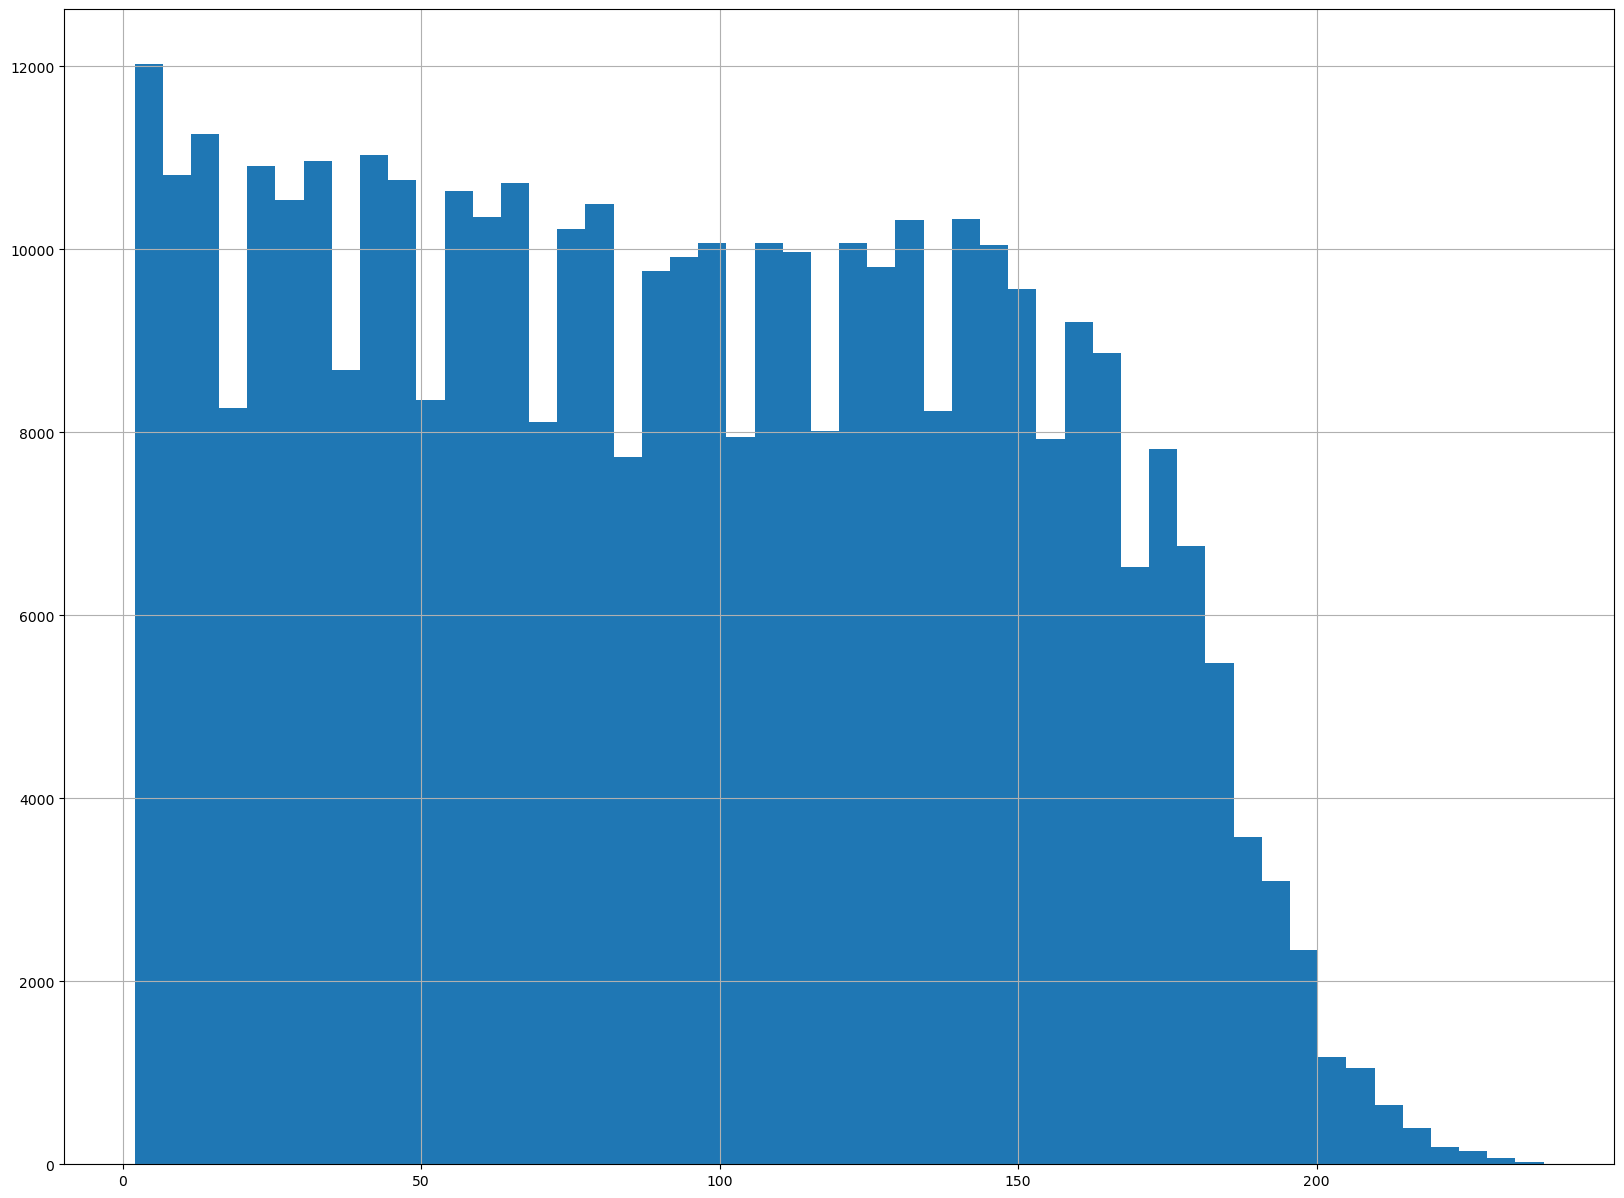

In [215]:
df_dropped['possession'].hist(bins=50, figsize=(20,15))

In [216]:
df_dropped['possession'].describe()

count    381267.000000
mean         92.618498
std          54.948467
min           2.000000
25%          45.000000
50%          91.000000
75%         138.000000
max         238.000000
Name: possession, dtype: float64

It is difficult to say whether the possession is for a specific player or the team. My guess is it per player as the min is 2 and I find it unlikely that a team has had only 2 possessions. Will clarify that in the following.

In [217]:
df_dropped[df_dropped['possession'] == df_dropped['possession'].min()]

,period,possession,location,under_pressure,possession_team.name,play_pattern.name,team.name,player.name,position.name,home_score,away_score,match_week,home_team.home_team_name,home_team.managers,away_team.away_team_name,away_team.managers,referee.name,won_foul,minute_bucket_0-9,minute_bucket_10-19,minute_bucket_20-29,minute_bucket_30-39,minute_bucket_40-49,minute_bucket_50-59,minute_bucket_60-69,minute_bucket_70-79,minute_bucket_80-89,minute_bucket_90-110
88199,0,2,"60.2, 40.7",0,Swansea City,From Kick Off,Swansea City,Jonjo Shelvey,Center Attacking Midfield,2,2,13,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88202,0,2,"52.4, 41.6",1,Swansea City,From Kick Off,Swansea City,Leon Britton,Right Defensive Midfield,2,2,13,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88205,0,2,"33.2, 60.9",0,Swansea City,From Kick Off,Swansea City,Kyle Bartley,Right Center Back,2,2,13,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88208,0,2,"28.5, 31.1",0,Swansea City,From Kick Off,Swansea City,Ashley Williams,Left Center Back,2,2,13,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88211,0,2,"26.8, 60.2",0,Swansea City,From Kick Off,Swansea City,Kyle Bartley,Right Center Back,2,2,13,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553335,0,2,"53.3, 10.2",0,Crystal Palace,From Kick Off,Crystal Palace,Yohan Cabaye,Right Defensive Midfield,1,2,12,Liverpool,"94, Jürgen Klopp, NA, 1967-06-16, 85, Germany",Crystal Palace,"382, Alan Pardew, NA, 1961-07-18, 68, England",Neil Swarbrick,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
553338,0,2,"13.5, 37.8",0,Crystal Palace,From Kick Off,Crystal Palace,Wayne Hennessey,Goalkeeper,1,2,12,Liverpool,"94, Jürgen Klopp, NA, 1967-06-16, 85, Germany",Crystal Palace,"382, Alan Pardew, NA, 1961-07-18, 68, England",Neil Swarbrick,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
553341,0,2,"5.8, 55.6",0,Crystal Palace,From Kick Off,Liverpool,Simon Mignolet,Goalkeeper,1,2,12,Liverpool,"94, Jürgen Klopp, NA, 1967-06-16, 85, Germany",Crystal Palace,"382, Alan Pardew, NA, 1961-07-18, 68, England",Neil Swarbrick,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
553346,0,2,"16.1, 17.5",0,Crystal Palace,From Kick Off,Liverpool,Mamadou Sakho,Left Center Back,1,2,12,Liverpool,"94, Jürgen Klopp, NA, 1967-06-16, 85, Germany",Crystal Palace,"382, Alan Pardew, NA, 1961-07-18, 68, England",Neil Swarbrick,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


It seems that the possessions is the total possessions from an individual player.

For location, it seems to be a 2D Cartesian grid with length being (0,120) and width being (0,80). Using this information, it is hard to determine whether (0,40) is always the home team's goal or if it is both the home teams and away teams. I am also not sure which side belongs to which team. It can change depending on the period as well. To simplify this and to still gather insight from this, the column is being converted into 4 sections. Length-wise, 2 (outer, middle), and breadth-wise will be 2 (wing, center). This will produce 4 different locations 
- outer wing
- outer center
- middle center
- middle wing

Finally, will one-hot encode the columns

In [218]:
df_dropped[['x', 'y']] = df_dropped['location'].str.split(',', expand=True)
df_dropped['x'] = df_dropped['x'].astype(float)
df_dropped['y'] = df_dropped['y'].astype(float)

df_dropped['x'].head(10)

88199    60.2
88202    52.4
88205    33.2
88208    28.5
88211    26.8
88214    31.0
88217    41.2
88220    24.1
88222     2.4
88224    15.5
Name: x, dtype: float64

In [219]:
def x_bucket(x):
    if pd.isna(x):
        return pd.NA
    if x < 40 or x >= 80:
        return 'outer'
    return 'middle'

def y_bucket(y):
    if pd.isna(y):
        return pd.NA
    if y < 26.6667 or y >= 53.3333:
        return 'wing'
    return 'center'

df_dropped['x_zone'] = df_dropped['x'].apply(x_bucket)
df_dropped['y_zone'] = df_dropped['y'].apply(y_bucket)

df_dropped['y_zone'].value_counts()

y_zone
wing      260698
center    120569
Name: count, dtype: int64

In [220]:
df_dropped['location_zone'] = df_dropped['x_zone'].fillna('Unknown').astype(str) + '_' + df_dropped['y_zone'].fillna('Unknown').astype(str)


df_dropped['location_zone'].value_counts()


location_zone
middle_wing      133111
outer_wing       127587
outer_center      65841
middle_center     54728
Name: count, dtype: int64

In [221]:
df_dropped = pd.get_dummies(df_dropped,dtype=int, columns=['location_zone'], drop_first=False)

In [222]:
df_dropped = df_dropped.drop(columns=['x', 'y', 'x_zone', 'y_zone','location'])


In [223]:
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   period                       381267 non-null  int64  
 1   possession                   381267 non-null  int64  
 2   under_pressure               381267 non-null  int64  
 3   possession_team.name         381267 non-null  object 
 4   play_pattern.name            381267 non-null  object 
 5   team.name                    381267 non-null  object 
 6   player.name                  381267 non-null  object 
 7   position.name                381267 non-null  object 
 8   home_score                   381267 non-null  int64  
 9   away_score                   381267 non-null  int64  
 10  match_week                   381267 non-null  int64  
 11  home_team.home_team_name     381267 non-null  object 
 12  home_team.managers           381267 non-null  object 
 13  

In [224]:
df_dropped['position.name'].value_counts()

position.name
Center Forward               36106
Left Back                    30411
Right Back                   30402
Center Attacking Midfield    29265
Left Wing                    25827
Right Wing                   25799
Left Center Back             25405
Right Center Back            24893
Left Defensive Midfield      21172
Right Defensive Midfield     20994
Left Center Midfield         19968
Right Center Midfield        19636
Right Midfield               13917
Left Midfield                13473
Goalkeeper                   11922
Right Center Forward          9673
Left Center Forward           9331
Center Defensive Midfield     8083
Right Wing Back               1413
Left Wing Back                1356
Center Back                    874
Right Attacking Midfield       677
Left Attacking Midfield        652
Center Midfield                 18
Name: count, dtype: int64

In [225]:
def map_position(pos):
    defense = {
        'Left Back', 'Right Back', 'Left Center Back', 'Right Center Back',
        'Center Back', 'Right Wing Back', 'Left Wing Back'
    }
    midfield = {
        'Center Attacking Midfield', 'Left Attacking Midfield', 'Right Attacking Midfield',
        'Left Defensive Midfield', 'Right Defensive Midfield', 'Center Defensive Midfield',
        'Left Center Midfield', 'Right Center Midfield', 'Center Midfield',
        'Right Midfield', 'Left Midfield'
    }
    forward = {
        'Center Forward', 'Right Center Forward', 'Left Center Forward',
        'Left Wing', 'Right Wing'
    }
    
    if pos == 'Goalkeeper':
        return 'Goalkeeper'
    elif pos in defense:
        return 'Defender'
    elif pos in midfield:
        return 'Midfielder'
    elif pos in forward:
        return 'Forward'
    else:
        return 'other'

df_dropped['grouped_position'] = df['position.name'].apply(map_position)

In [226]:
df_dropped['grouped_position'].value_counts()

grouped_position
Midfielder    147855
Defender      114754
Forward       106736
Goalkeeper     11922
Name: count, dtype: int64

In [227]:
df_dropped = pd.get_dummies(df_dropped, columns=['grouped_position'], drop_first=False, dtype=int) 

In [228]:
df_dropped = df_dropped.drop(columns=['position.name'])


In [229]:
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   period                       381267 non-null  int64  
 1   possession                   381267 non-null  int64  
 2   under_pressure               381267 non-null  int64  
 3   possession_team.name         381267 non-null  object 
 4   play_pattern.name            381267 non-null  object 
 5   team.name                    381267 non-null  object 
 6   player.name                  381267 non-null  object 
 7   home_score                   381267 non-null  int64  
 8   away_score                   381267 non-null  int64  
 9   match_week                   381267 non-null  int64  
 10  home_team.home_team_name     381267 non-null  object 
 11  home_team.managers           381267 non-null  object 
 12  away_team.away_team_name     381267 non-null  object 
 13  

### Group match weeks by quarters and then apply ordinal encoding

The quarter labels have a natural order:

1 = early season.

2 = first-middle season.

3 = second-middle season.

4 = late season

In [230]:
df_dropped['week_quarter'] = pd.cut(
    df_dropped['match_week'],
    bins=[0, 13, 26, 39, 53],
    labels=[1, 2, 3, 4],
    include_lowest=True,
    right=True
)


In [231]:
df_dropped['week_quarter'] = df_dropped['week_quarter'].astype(int)

In [232]:
df_dropped = df_dropped.drop(columns=['match_week'])

df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   period                       381267 non-null  int64  
 1   possession                   381267 non-null  int64  
 2   under_pressure               381267 non-null  int64  
 3   possession_team.name         381267 non-null  object 
 4   play_pattern.name            381267 non-null  object 
 5   team.name                    381267 non-null  object 
 6   player.name                  381267 non-null  object 
 7   home_score                   381267 non-null  int64  
 8   away_score                   381267 non-null  int64  
 9   home_team.home_team_name     381267 non-null  object 
 10  home_team.managers           381267 non-null  object 
 11  away_team.away_team_name     381267 non-null  object 
 12  away_team.managers           381267 non-null  object 
 13  

In [233]:
df_dropped.columns

Index(['period', 'possession', 'under_pressure', 'possession_team.name',
       'play_pattern.name', 'team.name', 'player.name', 'home_score',
       'away_score', 'home_team.home_team_name', 'home_team.managers',
       'away_team.away_team_name', 'away_team.managers', 'referee.name',
       'won_foul', 'minute_bucket_0-9', 'minute_bucket_10-19',
       'minute_bucket_20-29', 'minute_bucket_30-39', 'minute_bucket_40-49',
       'minute_bucket_50-59', 'minute_bucket_60-69', 'minute_bucket_70-79',
       'minute_bucket_80-89', 'minute_bucket_90-110',
       'location_zone_middle_center', 'location_zone_middle_wing',
       'location_zone_outer_center', 'location_zone_outer_wing',
       'grouped_position_Defender', 'grouped_position_Forward',
       'grouped_position_Goalkeeper', 'grouped_position_Midfielder',
       'week_quarter'],
      dtype='object')

In [234]:
df_cleaned = df_dropped.rename(columns={'possession_team.name': 'possession_team', 
                                        'play_pattern.name': 'play_pattern', 
                                        'team.name': 'team', 
                                        'player.name': 'player', 
                                        'home_team.managers': 'home_manager', 
                                        '_team.managers': 'play_pattern', 
                                        'home_team.home_team_name' : 'home_team',
                                        'play_pattern.name': 'play_pattern', 
                                        'away_team.away_team_name' : 'away_team',
                                        'away_team.managers': 'away_manager',
                                        'referee.name' : 'referee'})


In [235]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381267 entries, 88199 to 556452
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   period                       381267 non-null  int64  
 1   possession                   381267 non-null  int64  
 2   under_pressure               381267 non-null  int64  
 3   possession_team              381267 non-null  object 
 4   play_pattern                 381267 non-null  object 
 5   team                         381267 non-null  object 
 6   player                       381267 non-null  object 
 7   home_score                   381267 non-null  int64  
 8   away_score                   381267 non-null  int64  
 9   home_team                    381267 non-null  object 
 10  home_manager                 381267 non-null  object 
 11  away_team                    381267 non-null  object 
 12  away_manager                 381267 non-null  object 
 13  

In [236]:
df_cleaned.head(15)

,period,possession,under_pressure,possession_team,play_pattern,team,player,home_score,away_score,home_team,home_manager,away_team,away_manager,referee,won_foul,minute_bucket_0-9,minute_bucket_10-19,minute_bucket_20-29,minute_bucket_30-39,minute_bucket_40-49,minute_bucket_50-59,minute_bucket_60-69,minute_bucket_70-79,minute_bucket_80-89,minute_bucket_90-110,location_zone_middle_center,location_zone_middle_wing,location_zone_outer_center,location_zone_outer_wing,grouped_position_Defender,grouped_position_Forward,grouped_position_Goalkeeper,grouped_position_Midfielder,week_quarter
88199,0,2,0,Swansea City,From Kick Off,Swansea City,Jonjo Shelvey,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,1,1
88202,0,2,1,Swansea City,From Kick Off,Swansea City,Leon Britton,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,1,1
88205,0,2,0,Swansea City,From Kick Off,Swansea City,Kyle Bartley,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0,0,0,1
88208,0,2,0,Swansea City,From Kick Off,Swansea City,Ashley Williams,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,1
88211,0,2,0,Swansea City,From Kick Off,Swansea City,Kyle Bartley,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0,0,0,1
88214,0,2,0,Swansea City,From Kick Off,Swansea City,Ashley Williams,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,1
88217,0,2,0,Swansea City,From Kick Off,Swansea City,Sung-Yeung Ki,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,0,0,1,1
88220,0,2,0,Swansea City,From Kick Off,Swansea City,Ashley Williams,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,1
88222,0,2,0,Swansea City,From Kick Off,Swansea City,Łukasz Fabiański,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0,0,1,0,1
88224,0,2,0,Swansea City,From Kick Off,Swansea City,Ashley Williams,2,2,Swansea City,"270, Garry Monk, NA, 1979-03-06, 68, England",AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Andre Marriner,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,1,0,0,0,1


In [237]:
num_df = df_cleaned.select_dtypes(include=["number", "bool"]).copy()
corr_matrix = num_df.corr()
print(corr_matrix["won_foul"].sort_values(ascending=False))

won_foul                       1.000000
under_pressure                 0.051818
location_zone_middle_wing      0.027281
possession                     0.017272
location_zone_middle_center    0.013987
period                         0.013116
grouped_position_Midfielder    0.011724
minute_bucket_80-89            0.009446
minute_bucket_50-59            0.009179
minute_bucket_90-110           0.005175
minute_bucket_30-39            0.004431
minute_bucket_70-79            0.003850
minute_bucket_20-29            0.001982
grouped_position_Goalkeeper   -0.000633
minute_bucket_40-49           -0.001151
away_score                    -0.001213
week_quarter                  -0.001775
minute_bucket_60-69           -0.001880
minute_bucket_10-19           -0.002976
grouped_position_Forward      -0.004464
grouped_position_Defender     -0.007844
home_score                    -0.009288
location_zone_outer_center    -0.019952
location_zone_outer_wing      -0.021971
minute_bucket_0-9             -0.023831


In [238]:
#split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [239]:
X = df_cleaned.drop(columns=['won_foul'])
y = df_cleaned['won_foul']

#stratification in split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [243]:
# scale
scale_cols = ["possession", "week_quarter", "away_score", "home_score"]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [249]:
X_train.tail(15)

,period,possession,under_pressure,possession_team,play_pattern,team,player,home_score,away_score,home_team,home_manager,away_team,away_manager,referee,minute_bucket_0-9,minute_bucket_10-19,minute_bucket_20-29,minute_bucket_30-39,minute_bucket_40-49,minute_bucket_50-59,minute_bucket_60-69,minute_bucket_70-79,minute_bucket_80-89,minute_bucket_90-110,location_zone_middle_center,location_zone_middle_wing,location_zone_outer_center,location_zone_outer_wing,grouped_position_Defender,grouped_position_Forward,grouped_position_Goalkeeper,grouped_position_Midfielder,week_quarter
296079,1,0.697645,0,West Ham United,From Free Kick,Stoke City,Bojan Krkíc Pérez,-1.183445,-1.051344,West Ham United,"150, Slaven Bilić, NA, 1968-09-11, 56, Croatia",Stoke City,"55, Mark Hughes, NA, 1963-11-01, 249, Wales",Andre Marriner,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,0,0,1,0.028723
931008,0,-0.284522,0,Sunderland,Regular Play,Sunderland,Wahbi Khazri,-1.183445,0.677844,Sunderland,"561, Sam Allardyce, NA, 1954-10-19, 68, England",Leicester City,"60, Claudio Ranieri, NA, 1951-10-20, 112, Italy",Anthony Taylor,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1,1.259704
852404,0,-0.630099,0,Manchester City,From Throw In,West Ham United,Mark Noble,0.391241,0.677844,West Ham United,"150, Slaven Bilić, NA, 1968-09-11, 56, Croatia",Manchester City,"733, Manuel Luis Pellegrini Ripamonti, Manuel ...",Craig Pawson,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1,0.028723
623503,1,0.588515,0,Liverpool,Regular Play,Liverpool,Joe Gomez,-1.183445,-0.186750,Stoke City,"55, Mark Hughes, NA, 1963-11-01, 249, Wales",Liverpool,"6, Brendan Rodgers, NA, 1973-01-26, 169, North...",Anthony Taylor,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,-1.202258
690919,1,0.624892,0,Everton,From Throw In,Everton,Tom Cleverley,1.178585,-1.051344,Sunderland,"561, Sam Allardyce, NA, 1954-10-19, 68, England",Everton,"263, Roberto Martínez Montoliú, Roberto Martín...",Anthony Taylor,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0,1,0,1,0,0,1.259704
100900,1,0.479386,0,Sunderland,Regular Play,Sunderland,Patrick van Aanholt,-0.396102,1.542438,Sunderland,"453, Dick Advocaat, NA, 1947-09-27, 160, Nethe...",Norwich City,"41, Alex Neil, NA, 1981-06-09, 201, Scotland",Kevin Friend,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,-1.202258
895546,0,-0.102639,0,Sunderland,From Throw In,Sunderland,Jan Kirchhoff,-0.396102,-0.186750,Stoke City,"55, Mark Hughes, NA, 1963-11-01, 249, Wales",Sunderland,"561, Sam Allardyce, NA, 1954-10-19, 68, England",Craig Pawson,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0,0,0,1,1.259704
1086269,0,-0.211769,0,Chelsea,From Throw In,Chelsea,Willian Borges da Silva,-0.396102,2.407032,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Chelsea,"3608, Guus Hiddink, NA, 1946-11-08, 160, Nethe...",Roger East,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,1,0,0,1.259704
141723,0,-0.320898,0,Leicester City,From Throw In,Leicester City,Danny Drinkwater,-0.396102,-0.186750,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",Leicester City,"60, Claudio Ranieri, NA, 1951-10-20, 112, Italy",Neil Swarbrick,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1,-1.202258
118128,0,-0.666476,0,Stoke City,From Throw In,Stoke City,Marco van Ginkel,-1.183445,-0.186750,Stoke City,"55, Mark Hughes, NA, 1963-11-01, 249, Wales",West Bromwich Albion,"300, Tony Pulis, NA, 1958-01-16, 249, Wales",Michael Oliver,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,1,-1.202258


In [248]:
(X_train['possession_team'] != X_train['team']).value_counts(dropna=False)

False    281545
True      23468
Name: count, dtype: int64

For logistic training the model-
- removal of player as overfitting 
- removal of managers as although there were changes in managers in the season (example- Jugen Klopp)

In [250]:
X_train_log_reg = X_train.copy()
y_train_log_reg = y_train.copy()
X_test_log_reg = X_test.copy()
y_test_log_reg = y_test.copy()

In [255]:
X_train_log_reg = X_train_log_reg.drop(columns=[
    "player",
    "home_manager",
    "away_manager"
])

X_test_log_reg = X_test_log_reg.drop(columns=[
    "player",
    "home_manager",
    "away_manager"
])

In [256]:
#OHE
cat_cols = ["possession_team", "play_pattern", "team", "home_team", "away_team", "referee"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train_log_reg[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train_log_reg.index
)

test_ohe = pd.DataFrame(
    ohe.transform(X_test_log_reg[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test_log_reg.index
)

X_train_log_reg = X_train_log_reg.drop(columns=cat_cols).join(train_ohe)
X_test_log_reg = X_test_log_reg.drop(columns=cat_cols).join(test_ohe)

KeyError: "None of [Index(['possession_team', 'play_pattern', 'team', 'home_team', 'away_team',\n       'referee'],\n      dtype='object')] are in the [columns]"

In [257]:
X_train_log_reg.head(15)

,period,possession,under_pressure,home_score,away_score,minute_bucket_0-9,minute_bucket_10-19,minute_bucket_20-29,minute_bucket_30-39,minute_bucket_40-49,minute_bucket_50-59,minute_bucket_60-69,minute_bucket_70-79,minute_bucket_80-89,minute_bucket_90-110,location_zone_middle_center,location_zone_middle_wing,location_zone_outer_center,location_zone_outer_wing,grouped_position_Defender,grouped_position_Forward,grouped_position_Goalkeeper,grouped_position_Midfielder,week_quarter,possession_team_AFC Bournemouth,possession_team_Arsenal,possession_team_Aston Villa,possession_team_Chelsea,possession_team_Crystal Palace,possession_team_Everton,possession_team_Leicester City,possession_team_Liverpool,possession_team_Manchester City,possession_team_Manchester United,possession_team_Newcastle United,possession_team_Norwich City,possession_team_Southampton,possession_team_Stoke City,possession_team_Sunderland,possession_team_Swansea City,possession_team_Tottenham Hotspur,possession_team_Watford,possession_team_West Bromwich Albion,possession_team_West Ham United,play_pattern_From Corner,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,team_AFC Bournemouth,team_Arsenal,team_Aston Villa,team_Chelsea,team_Crystal Palace,team_Everton,team_Leicester City,team_Liverpool,team_Manchester City,team_Manchester United,team_Newcastle United,team_Norwich City,team_Southampton,team_Stoke City,team_Sunderland,team_Swansea City,team_Tottenham Hotspur,team_Watford,team_West Bromwich Albion,team_West Ham United,home_team_AFC Bournemouth,home_team_Arsenal,home_team_Aston Villa,home_team_Chelsea,home_team_Crystal Palace,home_team_Everton,home_team_Leicester City,home_team_Liverpool,home_team_Manchester City,home_team_Manchester United,home_team_Newcastle United,home_team_Norwich City,home_team_Southampton,home_team_Stoke City,home_team_Sunderland,home_team_Swansea City,home_team_Tottenham Hotspur,home_team_Watford,home_team_West Bromwich Albion,home_team_West Ham United,away_team_AFC Bournemouth,away_team_Arsenal,away_team_Aston Villa,away_team_Chelsea,away_team_Crystal Palace,away_team_Everton,away_team_Leicester City,away_team_Liverpool,away_team_Manchester City,away_team_Manchester United,away_team_Newcastle United,away_team_Norwich City,away_team_Southampton,away_team_Stoke City,away_team_Sunderland,away_team_Swansea City,away_team_Tottenham Hotspur,away_team_Watford,away_team_West Bromwich Albion,away_team_West Ham United,referee_Andre Marriner,referee_Anthony Taylor,referee_Craig Pawson,referee_Graham Scott,referee_Jonathan Moss,referee_Keith Stroud,referee_Kevin Friend,referee_Lee Mason,referee_Mark Clattenburg,referee_Martin Atkinson,referee_Michael Oliver,referee_Mike Dean,referee_Mike Jones,referee_Neil Swarbrick,referee_Paul Tierney,referee_Robert Madley,referee_Roger East,referee_Simon Hooper,referee_Stuart Attwell
668829,1,0.533951,0,-0.396102,0.677844,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,1.259704,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114343,0,-0.939300,0,0.391241,0.677844,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0,0,0,-1.202258,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_log_reg, y_train_log_reg)

# predictions
y_pred_log_reg = model.predict(X_test_log_reg)
y_prob_log_reg = model.predict_proba(X_test_log_reg)[:, 1]



[[67906     0]
 [ 8348     0]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67906
           1       0.00      0.00      0.00      8348

    accuracy                           0.89     76254
   macro avg       0.45      0.50      0.47     76254
weighted avg       0.79      0.89      0.84     76254

ROC AUC: 0.5780253052745155


c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [259]:
print(confusion_matrix(y_test_log_reg, y_pred_log_reg))
print('-------------------------------------------------------')
print(classification_report(y_test_log_reg, y_pred_log_reg))
print('-------------------------------------------------------')
print("ROC AUC:", roc_auc_score(y_test_log_reg, y_prob_log_reg))

[[67906     0]
 [ 8348     0]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67906
           1       0.00      0.00      0.00      8348

    accuracy                           0.89     76254
   macro avg       0.45      0.50      0.47     76254
weighted avg       0.79      0.89      0.84     76254

-------------------------------------------------------
ROC AUC: 0.5780253052745155


c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\arjun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


The confusion matrix and the classification report look good, however due to ROC AUC, this shows us that the model has only weak ability to rank positive cases above negative cases. I will then try to balance the class.

In [260]:

# model with balancing
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_log_reg, y_train_log_reg)

# predictions
y_pred_log_reg = model.predict(X_test_log_reg)
y_prob_log_reg = model.predict_proba(X_test_log_reg)[:, 1]

In [261]:
print(confusion_matrix(y_test_log_reg, y_pred_log_reg))
print('-------------------------------------------------------')
print(classification_report(y_test_log_reg, y_pred_log_reg))
print('-------------------------------------------------------')
print("ROC AUC:", roc_auc_score(y_test_log_reg, y_prob_log_reg))

[[38679 29227]
 [ 3810  4538]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.57      0.70     67906
           1       0.13      0.54      0.22      8348

    accuracy                           0.57     76254
   macro avg       0.52      0.56      0.46     76254
weighted avg       0.83      0.57      0.65     76254

-------------------------------------------------------
ROC AUC: 0.5781719837680857


The new model predicts won_foul as true more often due to the balancing. This helps with recall. I will try a tree-based model now.

In [264]:
X_train = X_train_log_reg
y_train = y_train_log_reg
X_test = X_test_log_reg
y_test = y_test_log_reg

In [265]:
#decision tree
tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

In [266]:

print(confusion_matrix(y_test, y_pred))
print('-----------------------------------------------')
print(classification_report(y_test, y_pred))
print('-----------------------------------------------')
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[36337 31569]
 [ 3731  4617]]
-----------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.54      0.67     67906
           1       0.13      0.55      0.21      8348

    accuracy                           0.54     76254
   macro avg       0.52      0.54      0.44     76254
weighted avg       0.82      0.54      0.62     76254

-----------------------------------------------
ROC AUC: 0.5566366123787538


ROC AUC is not improved using a decision tree, so I will try a Random Forest next.

In [272]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [273]:
print(confusion_matrix(y_test, y_pred))
print("-----------------------------------------------")
print(classification_report(y_test, y_pred))
print("-----------------------------------------------")
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[61673  6233]
 [ 3229  5119]]
-----------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     67906
           1       0.45      0.61      0.52      8348

    accuracy                           0.88     76254
   macro avg       0.70      0.76      0.72     76254
weighted avg       0.90      0.88      0.88     76254

-----------------------------------------------
ROC AUC: 0.8679175759549007


There are still many false positives and false negatives. I will now try BalancedRandomForestClassifier as this will help with class balancing

In [275]:
#balancedrandomforestclassifier
brf = BalancedRandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train, y_train)
y_pred = brf.predict(X_test)
y_prob = brf.predict_proba(X_test)[:, 1]

c:\Users\arjun\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:546: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
c:\Users\arjun\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:558: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(


In [276]:
print(confusion_matrix(y_test, y_pred))
print("-----------------------------------------------")
print(classification_report(y_test, y_pred))
print("-----------------------------------------------")
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[49667 18239]
 [ 2580  5768]]
-----------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     67906
           1       0.24      0.69      0.36      8348

    accuracy                           0.73     76254
   macro avg       0.60      0.71      0.59     76254
weighted avg       0.87      0.73      0.78     76254

-----------------------------------------------
ROC AUC: 0.7769085073716787
